Connected to das_env (Python 3.11.14)

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import das4whales as dw
import scipy.signal as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

DAS_APL_NAS_SERVER_PATH = "Z:/DAS-APL"; sys.path.append(DAS_APL_NAS_SERVER_PATH)

import processing.spectral_decomposition
import processing.get_clim
import processing.crop
import processing.normaliz_band

In [ ]:
filepath = 'Z:/DAS-APL/data/OOI_RCA2021/Optasence/NorthCable/C1_v2/North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T193002Z.h5'

metadata = dw.data_handle.get_acquisition_parameters(filepath, interrogator='optasense')

fs = metadata['fs']
dx = metadata['dx']
nx = metadata['nx']
ns = metadata['ns']

print(f'Sampling frequency: {fs} Hz')
print(f'Channel spacing: {dx} m')
print(f'Number of channels: {nx}, Number of time samples: {ns}')

#selected_channels_m = [0, nx*dx, dx]
selected_channels_m = [0, nx*dx, dx]
selected_channels = [int(x // dx) for x in selected_channels_m]

tr, time, dist, fileBeginTimeUTC = dw.data_handle.load_das_data(filepath, selected_channels, metadata)
print('Data shape:', tr.shape)

Sampling frequency: 200.0 Hz
Channel spacing: 2.0419046878814697 m
Number of channels: 32600, Number of time samples: 12000
Data shape: (15965, 12000)


In [13]:
B1 = [16, 20]   # Hz
B2 =  [20, 28]  # Hz
B3 = [3, 15]    # Hz

B_strain = [16, 28]

tr_b01, tr_b02, tr_b03, tr_strain = spectral_decomposition(tr, fs, [B1, B2, B3, B_strain])

In [14]:
t_min, t_max = 0, 60         # seconds
d_min, d_max = 00e3, 60e3    # meters

# tr_b01_c, dist_crop, time_crop = crop(tr_b01, dist, time, d_min, d_max, t_min, t_max)
# tr_b02_c, _,         _         = crop(tr_b02, dist, time, d_min, d_max, t_min, t_max)
# tr_b03_c, _,         _         = crop(tr_b03, dist, time, d_min, d_max, t_min, t_max)
# tr_strain_c, _,      _         = crop(tr_strain, dist, time, d_min, d_max, t_min, t_max)

tr_b01_c = tr_b01; tr_b02_c = tr_b02; tr_b03_c = tr_b03; tr_strain_c = tr_strain


In [15]:
b = normalize_band(tr_b03_c, perc=90)   # Blue:  low freq   3–15 Hz
g = normalize_band(tr_b02_c, perc=90)   # Green: mid freq  16–20 Hz
r = normalize_band(tr_b01_c, perc=90)   # Red:   high freq 20–28 Hz
rgb = np.stack([r, g, b], axis=-1)

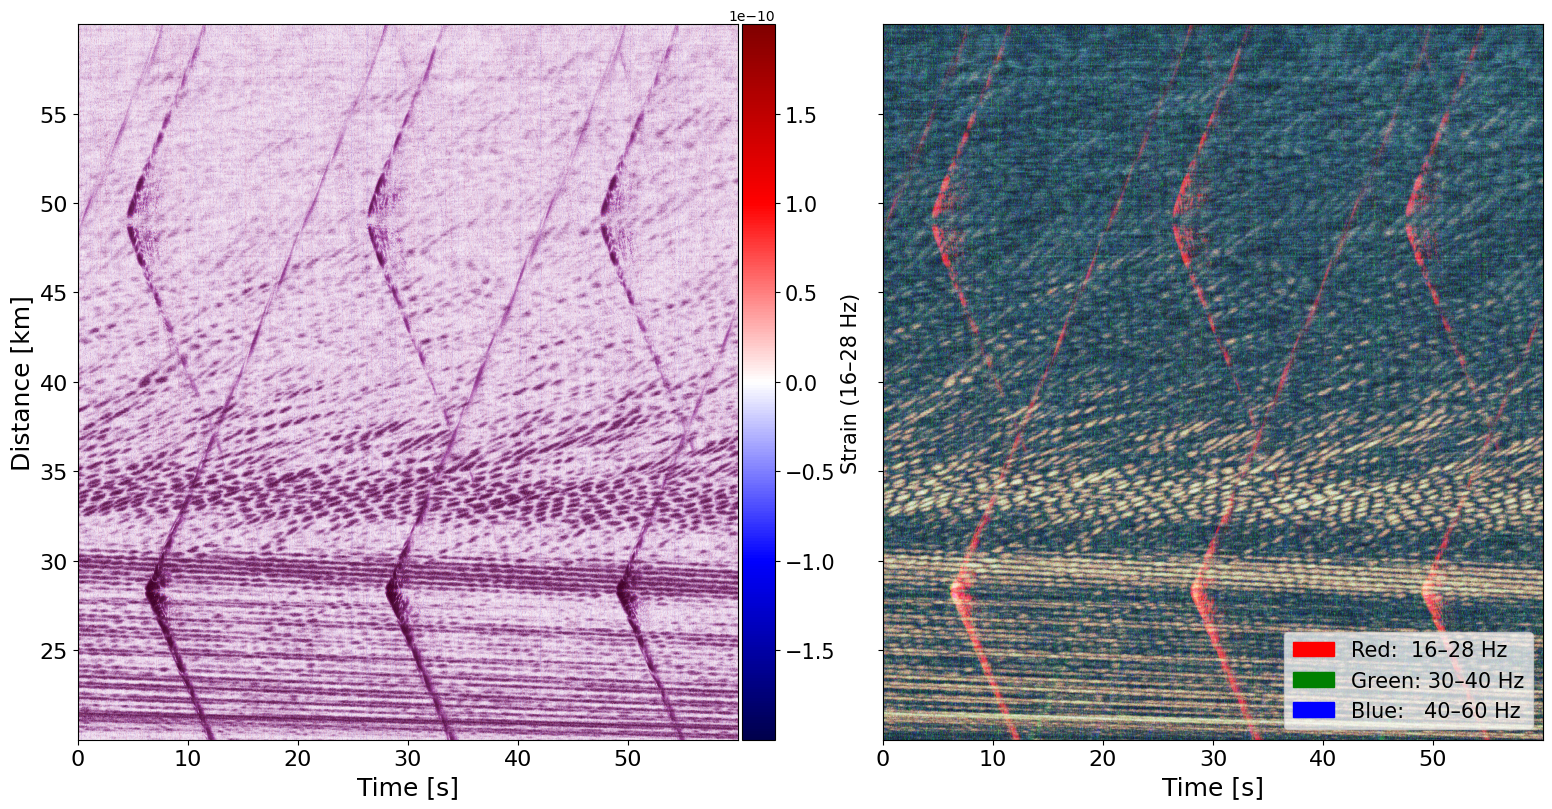

In [ ]:
LABEL_SIZE  = 18
TICK_SIZE   = 16
LEGEND_SIZE = 15
CBAR_SIZE   = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 8.2), sharey=True)

# --- LEFT: Strain ---
vmin, vmax = get_clim(tr_strain_c, perc=95)

im = axes[0].imshow(
    tr_strain_c,
    aspect='auto',
    origin='lower',
    cmap='seismic',
    vmin=vmin,
    vmax=vmax,
    extent=[time_crop[0], time_crop[-1],
            dist_crop[0] / 1e3, dist_crop[-1] / 1e3])

axes[0].set_xlabel('Time [s]', fontsize=LABEL_SIZE)
axes[0].set_ylabel('Distance [km]', fontsize=LABEL_SIZE)
axes[0].tick_params(axis='both', which='major', labelsize=TICK_SIZE)

divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax0)
cbar.set_label('Strain (16–28 Hz)', fontsize=CBAR_SIZE)
cbar.ax.tick_params(labelsize=CBAR_SIZE)

# --- RIGHT: RGB ---
axes[1].imshow(
    rgb,
    aspect='auto',
    origin='lower',
    extent=[time_crop[0], time_crop[-1],
            dist_crop[0] / 1e3, dist_crop[-1] / 1e3])

axes[1].set_xlabel('Time [s]', fontsize=LABEL_SIZE)
axes[1].tick_params(axis='both', which='major', labelsize=TICK_SIZE)

divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.04)
cax1.set_visible(False)

# legend = [
#     Patch(color='blue',  label=f'Blue:  {B1[0]}–{B1[1]} Hz'),
#     Patch(color='green', label=f'Green: {B2[0]}–{B2[1]} Hz'),
#     Patch(color='red',   label=f'Red:   {B3[0]}–{B3[1]} Hz'),
# ]
legend = [
    Patch(color='red',  label=f'Red:  {B3[0]}–{B3[1]} Hz'),
    Patch(color='green', label=f'Green: {B2[0]}–{B2[1]} Hz'),
    Patch(color='blue',   label=f'Blue:   {B1[0]}–{B1[1]} Hz'),
]
axes[1].legend(handles=legend, loc='lower right', framealpha=0.7, fontsize=LEGEND_SIZE)

plt.tight_layout()

In [ ]:
fig.savefig("Z:/DAS-APL/exp/multispectral_representation/Exp01-04.pdf",
            format="pdf", dpi=600, bbox_inches="tight", pad_inches=0.1)
fig.savefig("Z:/DAS-APL/exp/multispectral_representation/Exp01-04.png",
            format="png", dpi=600, bbox_inches="tight", pad_inches=0.1)

plt.show()